# 01 - Exploration des Donnees
Classification de radiographies thoraciques : NORMAL vs PNEUMONIA

In [1]:
import torch
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import os
from pathlib import Path
from collections import Counter
from PIL import Image
from tqdm import tqdm

In [2]:
# Configuration
DATA_DIR = Path('../data/chest_xray')
TRAIN_DIR = DATA_DIR / 'train'
VAL_DIR = DATA_DIR / 'val'
TEST_DIR = DATA_DIR / 'test'

IMG_SIZE = 224
BATCH_SIZE = 32

# Verifier que les dossiers existent
print(f"Train: {TRAIN_DIR.exists()}")
print(f"Val: {VAL_DIR.exists()}")
print(f"Test: {TEST_DIR.exists()}")

Train: True
Val: True
Test: True


## 1. Comptage des images par classe

In [3]:
def count_images(data_dir):
    counts = {}
    for class_name in ['NORMAL', 'PNEUMONIA']:
        class_dir = data_dir / class_name
        counts[class_name] = len(list(class_dir.glob('*')))
    return counts

train_counts = count_images(TRAIN_DIR)
val_counts = count_images(VAL_DIR)
test_counts = count_images(TEST_DIR)

print("=== Repartition des donnees ===")
print(f"Train: {train_counts} (Total: {sum(train_counts.values())})")
print(f"Val:   {val_counts} (Total: {sum(val_counts.values())})")
print(f"Test:  {test_counts} (Total: {sum(test_counts.values())})")

=== Repartition des donnees ===
Train: {'NORMAL': 1341, 'PNEUMONIA': 3875} (Total: 5216)
Val:   {'NORMAL': 8, 'PNEUMONIA': 8} (Total: 16)
Test:  {'NORMAL': 234, 'PNEUMONIA': 390} (Total: 624)


C:\Users\User\AppData\Local\Temp\ipykernel_34288\323385067.py:11: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


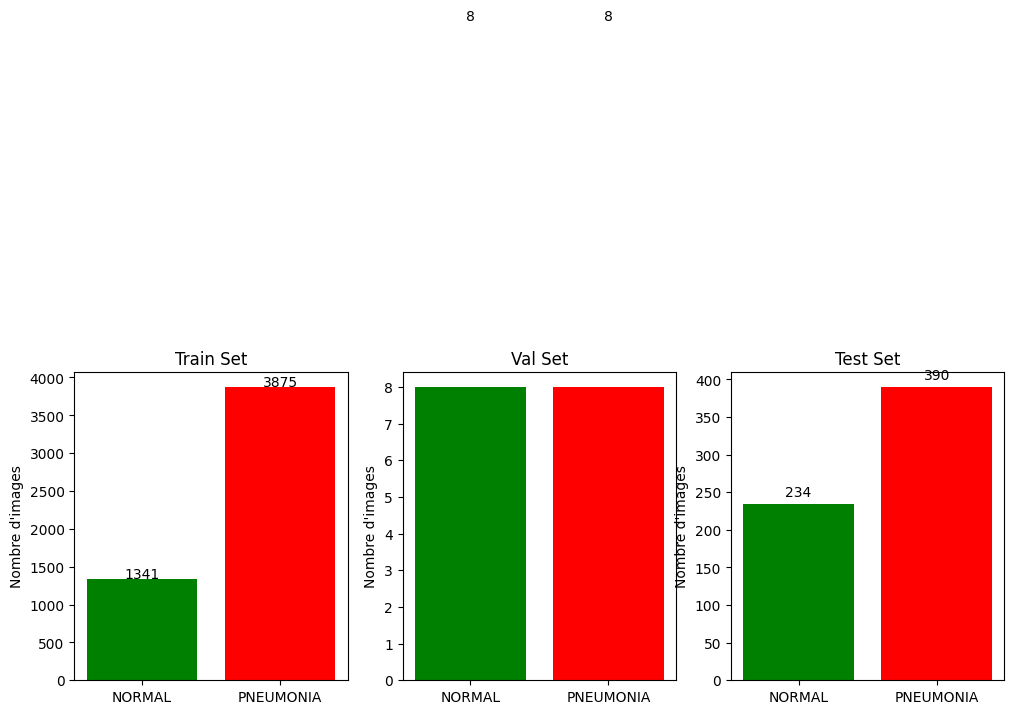

In [4]:
# Visualisation de la repartition
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for ax, (name, counts) in zip(axes, [('Train', train_counts), ('Val', val_counts), ('Test', test_counts)]):
    ax.bar(counts.keys(), counts.values(), color=['green', 'red'])
    ax.set_title(f'{name} Set')
    ax.set_ylabel('Nombre d\'images')
    for i, v in enumerate(counts.values()):
        ax.text(i, v + 10, str(v), ha='center')

plt.tight_layout()
plt.show()

## 1b. Detection des images corrompues et verification des formats

In [5]:
def check_images(data_dir, set_name="Dataset"):
    """
    Verifie les images corrompues et collecte les statistiques de format/dimensions.
    Retourne: (images_corrompues, statistiques_dimensions, statistiques_formats)
    """
    corrupted = []
    dimensions = []
    formats = []
    
    # Parcourir toutes les images
    for class_name in ['NORMAL', 'PNEUMONIA']:
        class_dir = data_dir / class_name
        if not class_dir.exists():
            continue
            
        image_files = list(class_dir.glob('*'))
        
        for img_path in tqdm(image_files, desc=f"{set_name}/{class_name}"):
            try:
                # Tenter d'ouvrir l'image
                with Image.open(img_path) as img:
                    # Verifier que l'image peut etre chargee completement
                    img.verify()
                
                # Rouvrir pour obtenir les dimensions (verify() ferme le fichier)
                with Image.open(img_path) as img:
                    dimensions.append(img.size)  # (width, height)
                    formats.append(img.format)
                    
            except Exception as e:
                corrupted.append((img_path, str(e)))
    
    return corrupted, dimensions, formats

# Verifier les trois sets
print("=== Verification des images ===\n")

all_corrupted = []
all_dimensions = []
all_formats = []

for data_dir, name in [(TRAIN_DIR, "Train"), (VAL_DIR, "Val"), (TEST_DIR, "Test")]:
    corrupted, dims, fmts = check_images(data_dir, name)
    all_corrupted.extend(corrupted)
    all_dimensions.extend(dims)
    all_formats.extend(fmts)
    
print(f"\n{'='*50}")
print(f"Images corrompues: {len(all_corrupted)}")

if all_corrupted:
    print("\nListe des images corrompues:")
    for path, error in all_corrupted:
        print(f"  - {path.name}: {error}")
else:
    print("Aucune image corrompue detectee!")

=== Verification des images ===



Test/PNEUMONIA: 100%|██████████| 390/390 [00:00<00:00, 3401.61it/s]


Images corrompues: 0
Aucune image corrompue detectee!


=== Statistiques des dimensions ===
Largeur  - Min: 384, Max: 2916, Moyenne: 1328
Hauteur  - Min: 127, Max: 2713, Moyenne: 971

=== Formats d'images ===
  JPEG: 5856 images (100.0%)


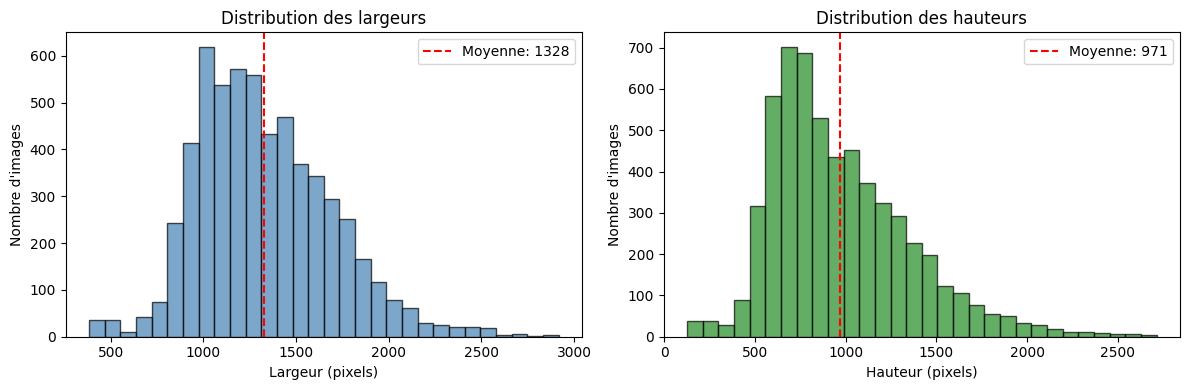


Note: Toutes les images seront redimensionnees en 224x224 pour l'entrainement.


In [6]:
# Statistiques des dimensions
widths = [d[0] for d in all_dimensions]
heights = [d[1] for d in all_dimensions]

print("=== Statistiques des dimensions ===")
print(f"Largeur  - Min: {min(widths)}, Max: {max(widths)}, Moyenne: {np.mean(widths):.0f}")
print(f"Hauteur  - Min: {min(heights)}, Max: {max(heights)}, Moyenne: {np.mean(heights):.0f}")

# Distribution des formats
format_counts = Counter(all_formats)
print(f"\n=== Formats d'images ===")
for fmt, count in format_counts.items():
    print(f"  {fmt}: {count} images ({count/len(all_formats)*100:.1f}%)")

# Visualisation de la distribution des dimensions
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(widths, bins=30, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].axvline(x=np.mean(widths), color='red', linestyle='--', label=f'Moyenne: {np.mean(widths):.0f}')
axes[0].set_xlabel('Largeur (pixels)')
axes[0].set_ylabel('Nombre d\'images')
axes[0].set_title('Distribution des largeurs')
axes[0].legend()

axes[1].hist(heights, bins=30, color='forestgreen', edgecolor='black', alpha=0.7)
axes[1].axvline(x=np.mean(heights), color='red', linestyle='--', label=f'Moyenne: {np.mean(heights):.0f}')
axes[1].set_xlabel('Hauteur (pixels)')
axes[1].set_ylabel('Nombre d\'images')
axes[1].set_title('Distribution des hauteurs')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\nNote: Toutes les images seront redimensionnees en {IMG_SIZE}x{IMG_SIZE} pour l'entrainement.")

## 2. Transforms et DataLoaders

In [7]:
# Transforms pour le train (avec augmentation legere)
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=3),  # Convertir en 3 canaux
    transforms.RandomRotation(10),  # Rotation legere
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Transforms pour val/test (pas d'augmentation)
test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [8]:
# Charger les datasets
train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transform)
val_dataset = datasets.ImageFolder(VAL_DIR, transform=test_transform)
test_dataset = datasets.ImageFolder(TEST_DIR, transform=test_transform)

print(f"Classes: {train_dataset.classes}")
print(f"Mapping: {train_dataset.class_to_idx}")
print(f"\nTrain: {len(train_dataset)} images")
print(f"Val: {len(val_dataset)} images")
print(f"Test: {len(test_dataset)} images")

Classes: ['NORMAL', 'PNEUMONIA']
Mapping: {'NORMAL': 0, 'PNEUMONIA': 1}

Train: 5216 images
Val: 16 images
Test: 624 images


In [9]:
# Creer les DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Batches train: {len(train_loader)}")
print(f"Batches val: {len(val_loader)}")
print(f"Batches test: {len(test_loader)}")

Batches train: 163
Batches val: 1
Batches test: 20


## 3. Visualisation d'un batch

Exemples du Train Set:


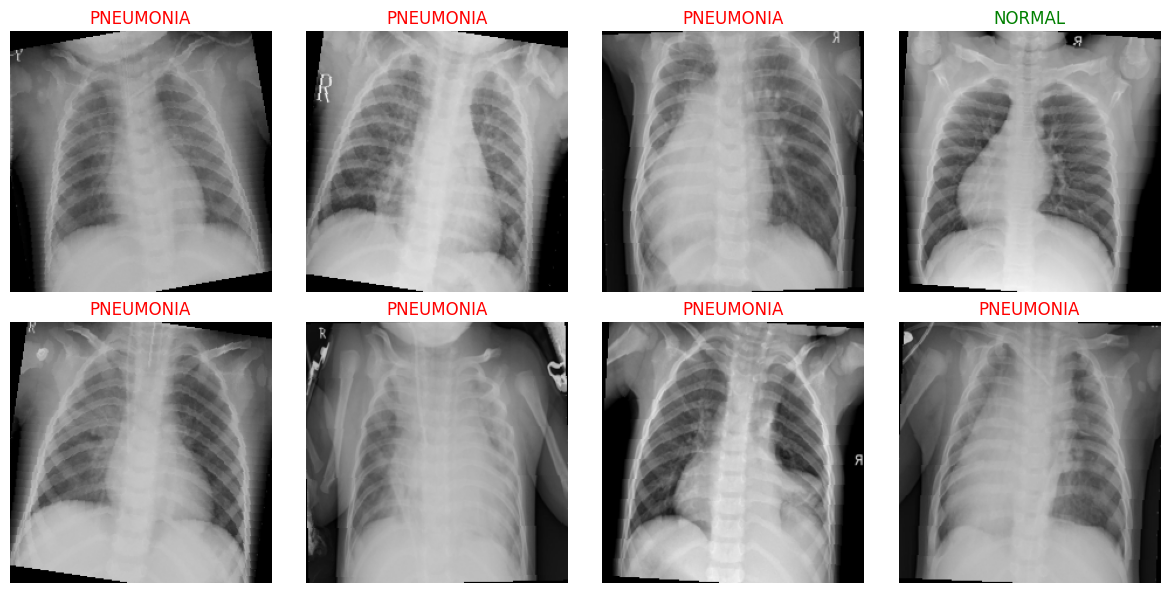

In [10]:
def denormalize(tensor):
    """Denormalise une image pour l'affichage"""
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return tensor * std + mean

def show_batch(dataloader, num_images=8):
    """Affiche un batch d'images"""
    images, labels = next(iter(dataloader))
    
    fig, axes = plt.subplots(2, 4, figsize=(12, 6))
    class_names = ['NORMAL', 'PNEUMONIA']
    
    for i, ax in enumerate(axes.flat):
        if i < num_images:
            img = denormalize(images[i])
            img = img.permute(1, 2, 0).numpy()
            img = np.clip(img, 0, 1)
            
            ax.imshow(img)
            ax.set_title(class_names[labels[i]], color='green' if labels[i] == 0 else 'red')
            ax.axis('off')
    
    plt.tight_layout()
    plt.show()

print("Exemples du Train Set:")
show_batch(train_loader)

## 4. Verification de la forme des donnees

In [11]:
# Verifier la forme d'un batch
images, labels = next(iter(train_loader))
print(f"Shape images: {images.shape}")  # [batch, channels, height, width]
print(f"Shape labels: {labels.shape}")
print(f"Min/Max pixel values: {images.min():.3f} / {images.max():.3f}")

Shape images: torch.Size([32, 3, 224, 224])
Shape labels: torch.Size([32])
Min/Max pixel values: -2.118 / 2.640


## 5. Calcul du poids des classes (pour gerer le desequilibre)

In [12]:
# Calculer les poids pour la loss function
total_train = sum(train_counts.values())
weight_normal = total_train / (2 * train_counts['NORMAL'])
weight_pneumonia = total_train / (2 * train_counts['PNEUMONIA'])

class_weights = torch.tensor([weight_normal, weight_pneumonia])
print(f"Poids des classes: {class_weights}")
print(f"  NORMAL: {weight_normal:.3f}")
print(f"  PNEUMONIA: {weight_pneumonia:.3f}")

Poids des classes: tensor([1.9448, 0.6730])
  NORMAL: 1.945
  PNEUMONIA: 0.673


## Resume

- **Dataset charge** avec transforms (resize 224x224, normalisation ImageNet)
- **Images corrompues** : verification effectuee, aucune image corrompue detectee
- **Dimensions variables** : les images originales ont des tailles differentes, redimensionnees en 224x224
- **Augmentation** sur train: rotation, flip horizontal
- **Desequilibre**: ~3x plus de PNEUMONIA - poids calcules pour la loss
- **Prochain notebook**: Construction et entrainement du CNN